## Data prepoccessing

In [148]:
import pandas as pd
df = pd.read_csv('../data/words10.csv')
df.head()

,model,language,1,2,3,4,5,6,7,8,9,10,genre,age
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder,None,None
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody,None,None
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow,None,None
3,gpt_53_chat,french,montagne,chaise,tempête,parfum,miroir,silence,rivière,enfance,liberté,sourire,None,None
4,gpt_53_chat,french,arbre,liberté,cuillère,tempête,parfum,horloge,sable,musique,fenêtre,sourire,None,None


In [149]:
# Remove accents and convert to lowercase
import unicodedata

def remove_accents_and_whitespace(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)]).strip()

word_cols = df.columns[2:-2]  # The first two and last two columns are not words
for col in word_cols:
    df[col] = df[col].apply(lambda x: remove_accents_and_whitespace(x).lower())


df = df.drop(['genre', 'age'], axis=1)
df.head()

,model,language,1,2,3,4,5,6,7,8,9,10
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,liberte,sourire
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,fenetre,sourire


In [150]:
df.to_csv('../data/words10_cleaned.csv', index=False)

## Score per entry

In [141]:
# What are the max and min scores possibles ????

# min score = -1/(n-1) = -0.111 (according to Gemini)

In [151]:
# Calculate embeddings

from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

df_embeddings = df.copy()

word_cols = df.columns[2:-2]

for col in word_cols:
    df_embeddings[col] = df_embeddings[col].apply(lambda w: model.encode(w))

df_embeddings.to_csv('../data/words10_embeddings_paraphrase-multilingual-MiniLM-L12-v2.csv', index=False)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4863.06it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# Calculate average, min and maxcosine similarity per row
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_similarity(row):
    word_cols = row.index[2:-2]
    embeddings = [row[col] for col in word_cols]
    
    if len(embeddings) < 2:
        return pd.Series({'avg_cosine': None, 'min_cosine': None, 'max_cosine': None})
    
    similarities = cosine_similarity(embeddings)
    
    # Get upper triangle of the similarity matrix, excluding the diagonal
    upper_triangle = similarities[np.triu_indices_from(similarities, k=1)]
    
    avg_cosine = np.mean(upper_triangle)
    min_cosine = np.min(upper_triangle)
    max_cosine = np.max(upper_triangle)
    
    return pd.Series({'avg_cosine': avg_cosine, 'min_cosine': min_cosine, 'max_cosine': max_cosine})

similarity_df = df_embeddings.apply(calculate_similarity, axis=1)

# Combine with original dataframe
similarity_df = pd.concat([df[df.columns[:2]], similarity_df], axis=1)
similarity_df.head()

,model,language,avg_cosine,min_cosine,max_cosine
0,gpt_53_chat,english,0.227187,0.032564,0.554003
1,gpt_53_chat,english,0.237164,0.081812,0.554003
2,gpt_53_chat,english,0.188208,-0.001801,0.487942
3,gpt_53_chat,french,0.448684,0.166499,0.742863
4,gpt_53_chat,french,0.531643,0.143482,0.829557


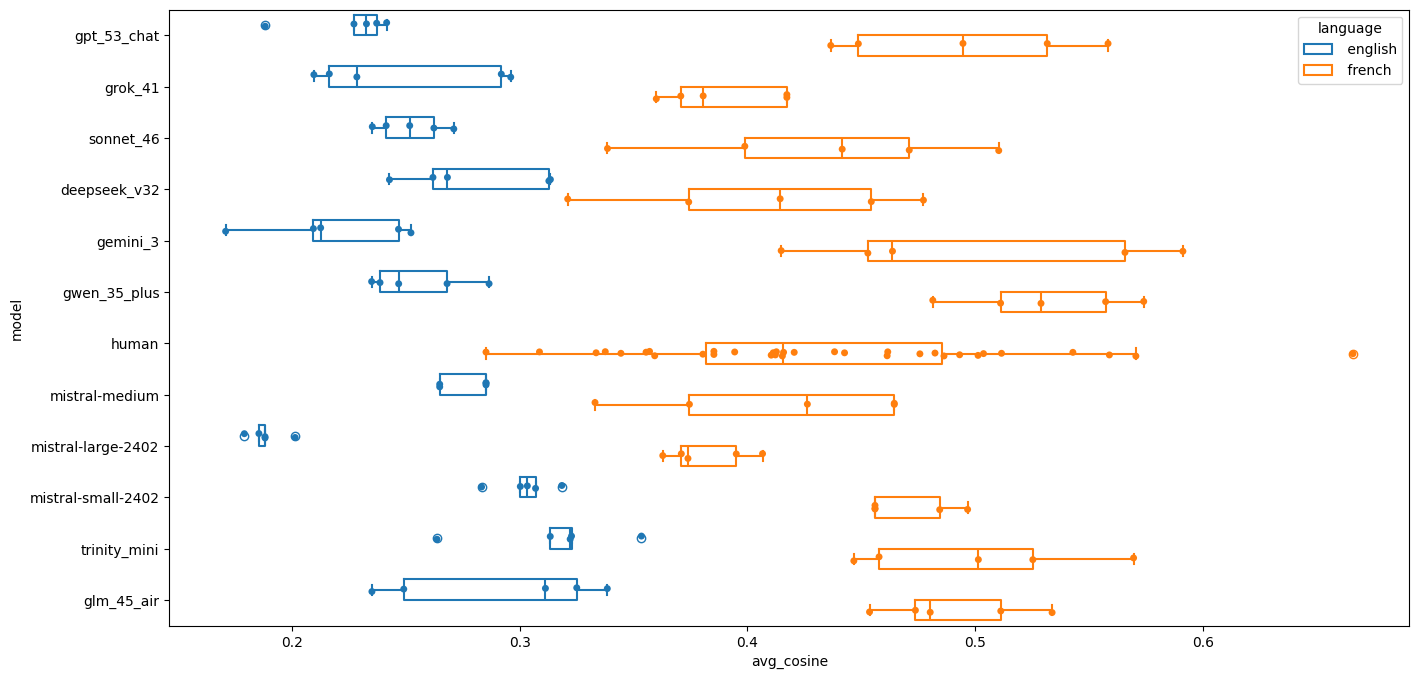

In [45]:
# make some plots
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 1, figsize=(16, 8))

sns.boxplot(data=similarity_df, x="avg_cosine", y="model", hue="language", ax=axes, fill=False)
sns.stripplot(data=similarity_df, x="avg_cosine", y="model", hue="language", dodge=True, jitter=True, ax=axes, legend=False)

plt.show()

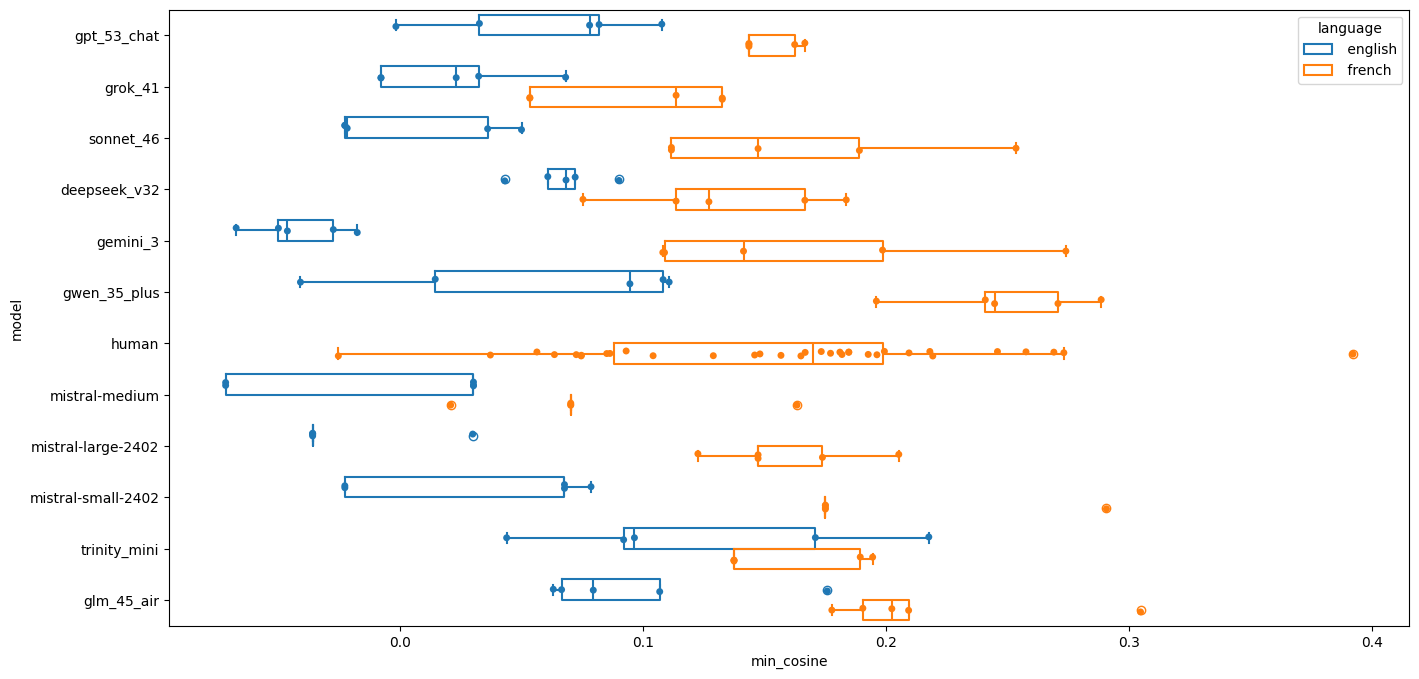

In [46]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

sns.boxplot(data=similarity_df, x="min_cosine", y="model", hue="language", ax=axes, fill=False)
sns.stripplot(data=similarity_df, x="min_cosine", y="model", hue="language", dodge=True, jitter=True, ax=axes, legend=False)

plt.show()

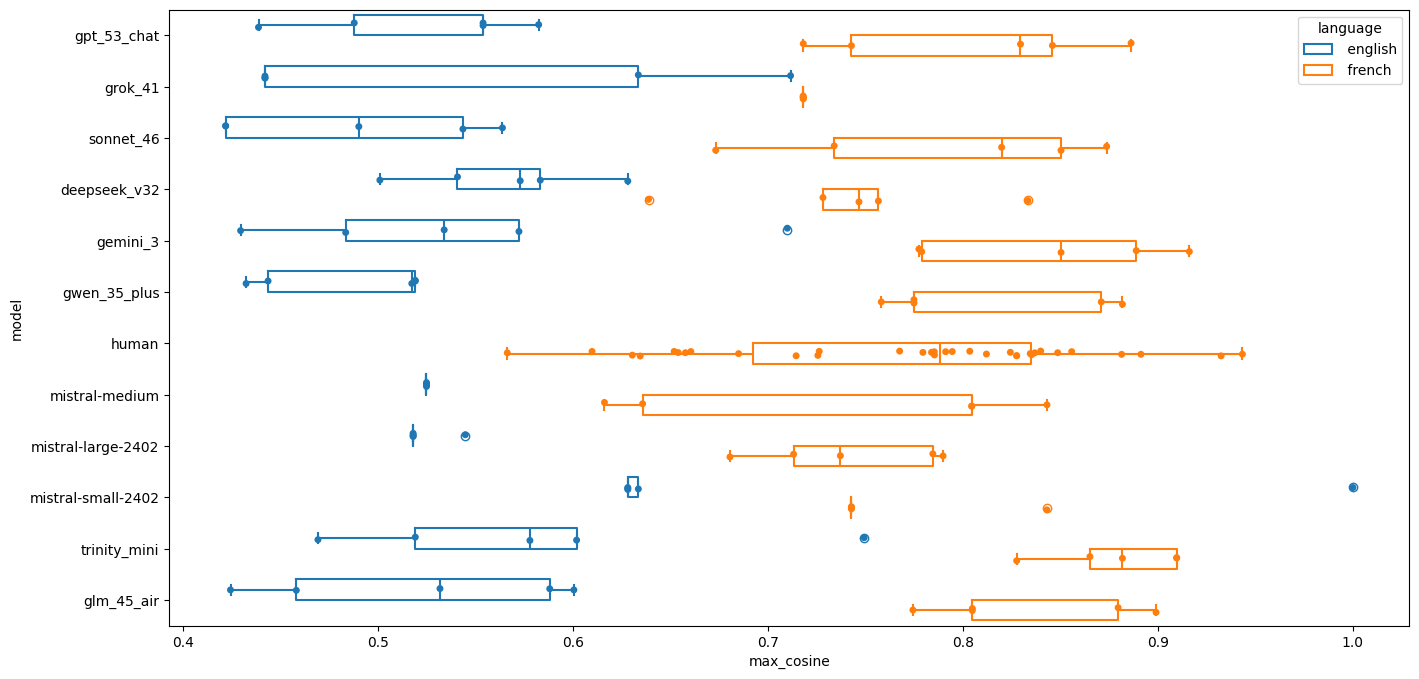

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

sns.boxplot(data=similarity_df, x="max_cosine", y="model", hue="language", ax=axes, fill=False)
sns.stripplot(data=similarity_df, x="max_cosine", y="model", hue="language", dodge=True, jitter=True, ax=axes, legend=False)

plt.show()

## Similairity in between entries

In [48]:
# Calculate the avarage embedding per row and save it to a new column
def calculate_average_embedding(row):
    word_cols = row.index[2:-2]
    embeddings = [row[col] for col in word_cols]

    avg_embedding = np.mean(embeddings, axis=0)
    return avg_embedding

similarity_df['avg_embedding'] = df_embeddings.apply(calculate_average_embedding, axis=1)
similarity_df.head()

,model,language,avg_cosine,min_cosine,max_cosine,avg_embedding
0,gpt_53_chat,english,0.227187,0.032564,0.554003,"[-0.020617735, 0.12616083, 0.15300474, 0.05832..."
1,gpt_53_chat,english,0.237164,0.081812,0.554003,"[-0.09396628, 0.05356857, 0.12973477, 0.120497..."
2,gpt_53_chat,english,0.188208,-0.001801,0.487942,"[-0.0781631, 0.033433933, -0.055128764, 0.1404..."
3,gpt_53_chat,french,0.448684,0.166499,0.742863,"[0.10979865, 0.1508427, 0.03342708, 0.07254411..."
4,gpt_53_chat,french,0.531643,0.143482,0.829557,"[-0.0032596246, 0.12462518, -0.040952433, 0.03..."


In [67]:
# Sort similarity_df by model and language
similarity_df = similarity_df.sort_values(by=['model', 'language']).reset_index(drop=True)

similarity_df_en = similarity_df.loc[similarity_df['language'] == ' english']
similarity_df_fr = similarity_df[similarity_df['language'] == ' french']

# Calculate cosine similarity matrix
similarity_matrix_en = cosine_similarity(similarity_df_en['avg_embedding'].tolist())
similarity_matrix_fr = cosine_similarity(similarity_df_fr['avg_embedding'].tolist())

Text(0.5, 1.0, 'Cosine Similarity Matrix of Average Embeddings')

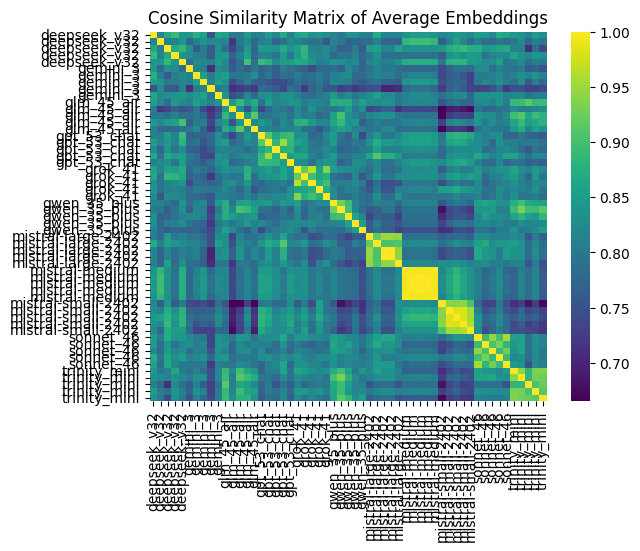

In [68]:
sns.heatmap(similarity_matrix_en, xticklabels=similarity_df_en['model'], yticklabels=similarity_df_en['model'], cmap='viridis')
plt.title('Cosine Similarity Matrix of Average Embeddings')

Text(0.5, 1.0, 'Cosine Similarity Matrix of Average Embeddings')

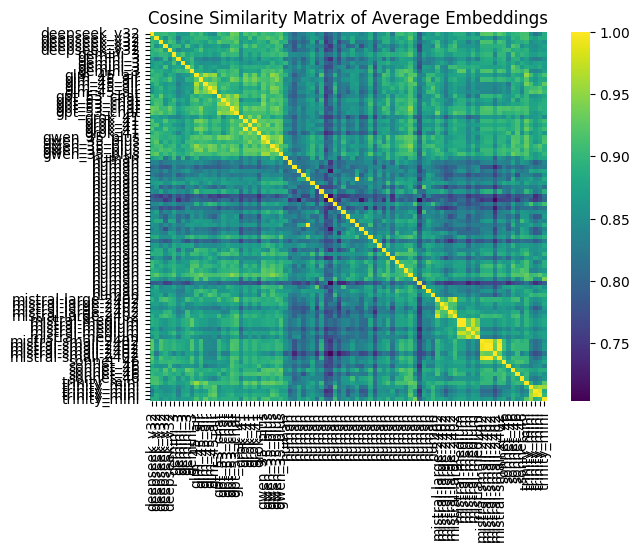

In [69]:
sns.heatmap(similarity_matrix_fr, xticklabels=similarity_df_fr['model'], yticklabels=similarity_df_fr['model'], cmap='viridis')
plt.title('Cosine Similarity Matrix of Average Embeddings')

In [ ]:
# Calculate a average embedding per model and language and save in a df

grouped_embeddings = (
    similarity_df
    .groupby(["model", "language"])["avg_embedding"]
    .apply(lambda x: np.mean(np.vstack(x), axis=0))
    .reset_index()
)



grouped_embeddings.head()


,model,language,avg_embedding
0,deepseek_v32,english,"[0.0058316947, 0.124046005, 0.017490136, 0.127..."
1,deepseek_v32,french,"[0.057573505, 0.12188365, 0.002912926, 0.02009..."
2,gemini_3,english,"[-0.002856177, 0.11502664, 0.008260292, 0.0672..."
3,gemini_3,french,"[0.029842133, 0.09049143, -0.015244591, 0.0652..."
4,glm_45_air,english,"[0.07566555, 0.1915501, 0.021241423, 0.1403730..."


In [74]:
# calculate cosine similarity between all rows and save it to a new column

grouped_embeddings_en = grouped_embeddings.loc[grouped_embeddings['language'] == ' english']
grouped_embeddings_fr = grouped_embeddings.loc[grouped_embeddings['language'] == ' french']

avg_cosine_sim_en = cosine_similarity(grouped_embeddings_en['avg_embedding'].tolist())
avg_cosine_sim_fr = cosine_similarity(grouped_embeddings_fr['avg_embedding'].tolist())

Text(0.5, 1.0, 'Cosine Similarity Matrix of Average Embeddings')

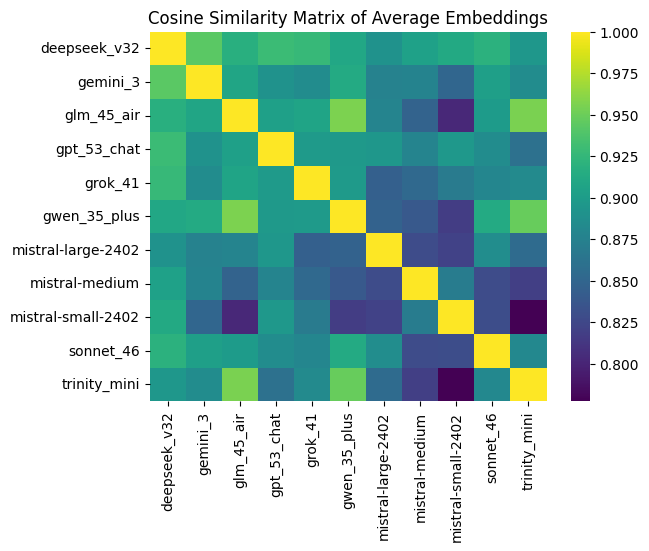

In [75]:
sns.heatmap(avg_cosine_sim_en, xticklabels=grouped_embeddings_en['model'], yticklabels=grouped_embeddings_en['model'], cmap='viridis')
plt.title('Cosine Similarity Matrix of Average Embeddings')

Text(0.5, 1.0, 'Cosine Similarity Matrix of Average Embeddings')

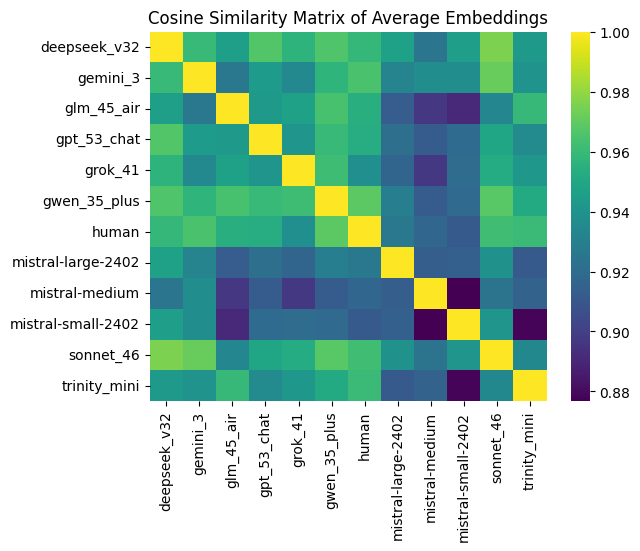

In [76]:
sns.heatmap(avg_cosine_sim_fr, xticklabels=grouped_embeddings_fr['model'], yticklabels=grouped_embeddings_fr['model'], cmap='viridis')
plt.title('Cosine Similarity Matrix of Average Embeddings')

## PCA

In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_res_en = pca.fit_transform(similarity_df_en['avg_embedding'].tolist())
pca_res_fr = pca.fit_transform(similarity_df_fr['avg_embedding'].tolist())

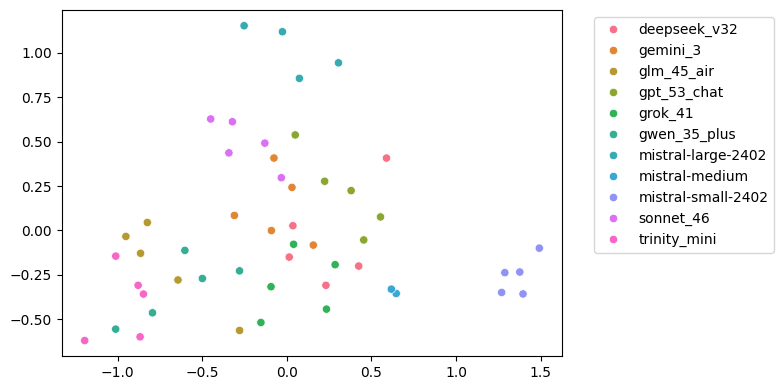

In [93]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

sns.scatterplot(x=pca_res_en[:, 0], y=pca_res_en[:, 1], hue=similarity_df_en['model'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



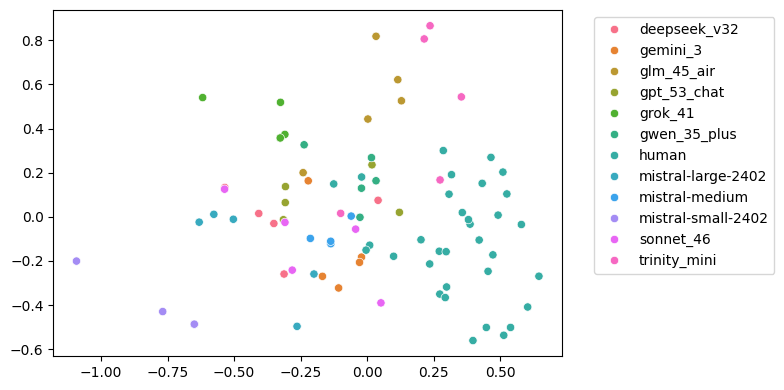

In [94]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

sns.scatterplot(x=pca_res_fr[:, 0], y=pca_res_fr[:, 1], hue=similarity_df_fr['model'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [97]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_res_en = tsne.fit_transform(np.vstack(similarity_df_en['avg_embedding'].tolist()))
tsne_res_fr = tsne.fit_transform(np.vstack(similarity_df_fr['avg_embedding'].tolist()))

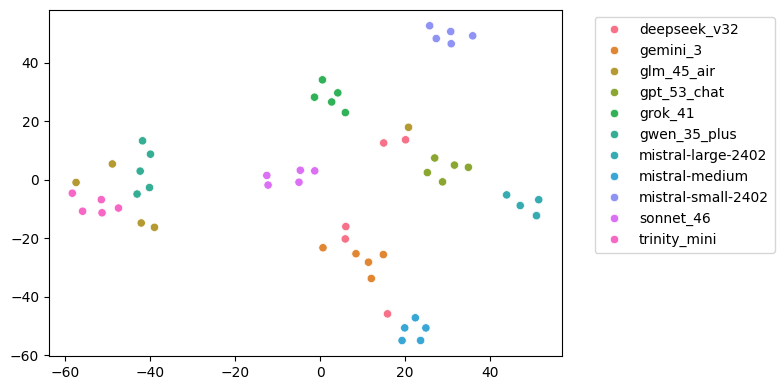

In [98]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

sns.scatterplot(x=tsne_res_en[:, 0], y=tsne_res_en[:, 1], hue=similarity_df_en['model'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

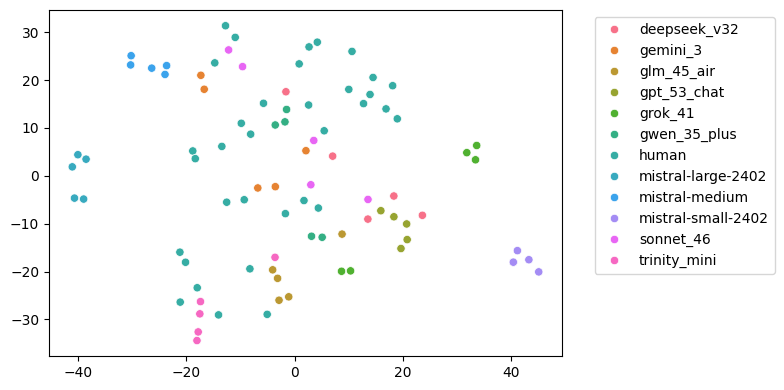

In [99]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

sns.scatterplot(x=tsne_res_fr[:, 0], y=tsne_res_fr[:, 1], hue=similarity_df_fr['model'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [100]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_res = tsne.fit_transform(np.vstack(similarity_df['avg_embedding'].tolist()))

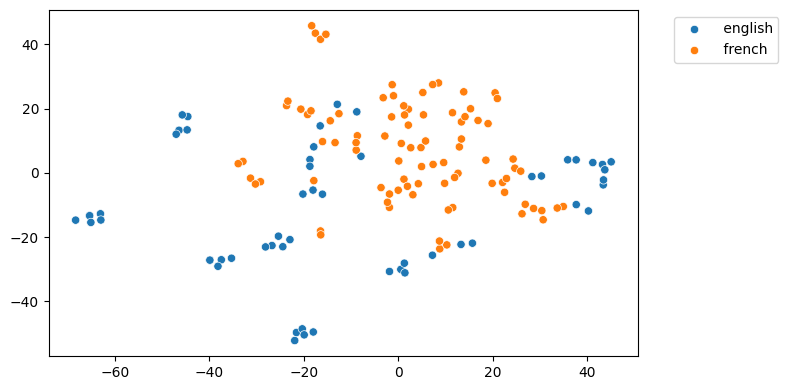

In [102]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

sns.scatterplot(x=tsne_res[:, 0], y=tsne_res[:, 1], hue=similarity_df['language'])

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Word cloud

In [103]:
df.head()

,model,language,1,2,3,4,5,6,7,8,9,10,genre,age
0,gpt_53_chat,english,pebble,thunder,pillow,forest,mirror,bread,shadow,ocean,silence,ladder,None,None
1,gpt_53_chat,english,mountain,spoon,thunder,library,childhood,ocean,mirror,bread,shadow,melody,None,None
2,gpt_53_chat,english,mountain,toothbrush,democracy,kitten,thunder,pillow,rainbow,hunger,library,shadow,None,None
3,gpt_53_chat,french,montagne,chaise,tempete,parfum,miroir,silence,riviere,enfance,liberte,sourire,None,None
4,gpt_53_chat,french,arbre,liberte,cuillere,tempete,parfum,horloge,sable,musique,fenetre,sourire,None,None


In [131]:
# Take all words

# Split in french, english and human
words_en = df[(df['language'] == ' english') & (df['model'] != ' human')][df.columns[2:-2]]
words_fr = df[(df['language'] == ' french') & (df['model'] != ' human')][df.columns[2:-2]]
words_human = df[df['model'] == 'human'][df.columns[2:-2]]

# convert to strings
words_en = words_en.apply(lambda x: ' '.join(x), axis=1)
words_fr = words_fr.apply(lambda x: ' '.join(x), axis=1)
words_human = words_human.apply(lambda x: ' '.join(x), axis=1)

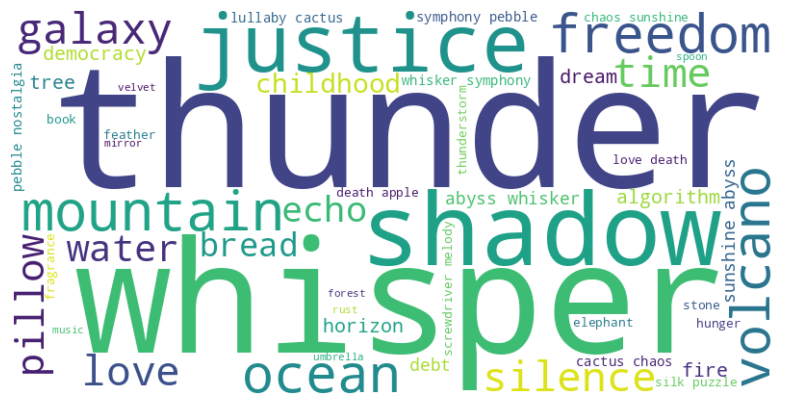

In [113]:
from wordcloud import WordCloud

wordcloud_en = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(' '.join(words_en))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_en, interpolation='bilinear')
plt.axis('off')
plt.show()

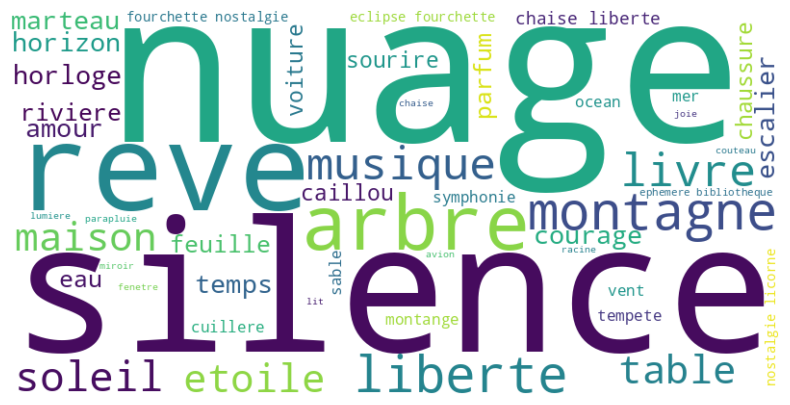

In [115]:
wordcloud_fr = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(' '.join(words_fr))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fr, interpolation='bilinear')
plt.axis('off')
plt.show()

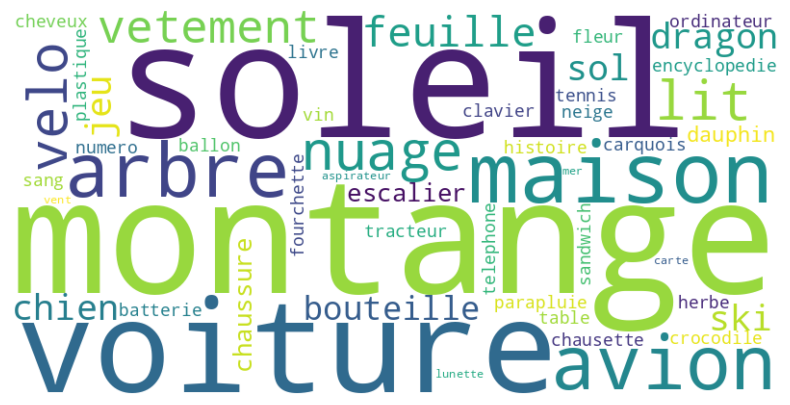

In [118]:
wordcloud_human = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(' '.join(words_human))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.axis('off')
plt.show()

In [137]:
# For the LLM : filter unique words per model


# Split in french, english and human
words_en = df[(df['language'] == ' english') & (df['model'] != ' human')][df.columns]
words_fr = df[(df['language'] == ' french') & (df['model'] != ' human')][df.columns]

# Group by model and get unique words
words_en_grouped = (
    words_en
    .groupby("model")[words_en.columns[2:-2]]
    .apply(lambda x: pd.unique(x.values.ravel()))
)
words_fr_grouped = (
    words_fr
    .groupby("model")[words_fr.columns[2:-2]]
    .apply(lambda x: pd.unique(x.values.ravel()))
)

# Extract all words and convert to strings
all_words_en = ' '.join(words_en_grouped.explode().astype(str))
all_words_fr = ' '.join(words_fr_grouped.explode().astype(str))

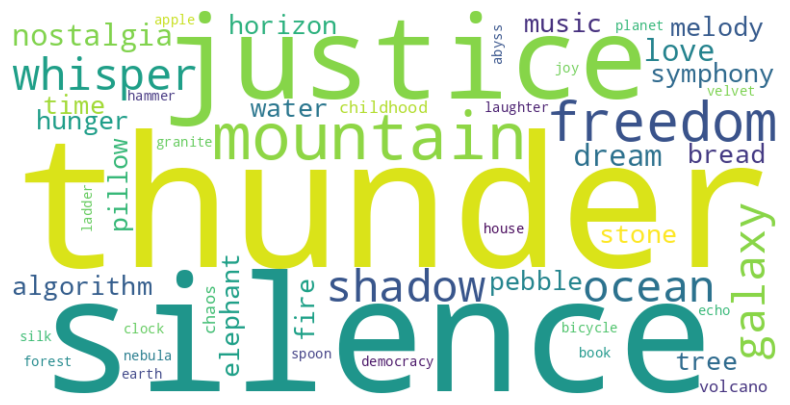

In [138]:
wordcloud_en = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(all_words_en)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_en, interpolation='bilinear')
plt.axis('off')
plt.show()

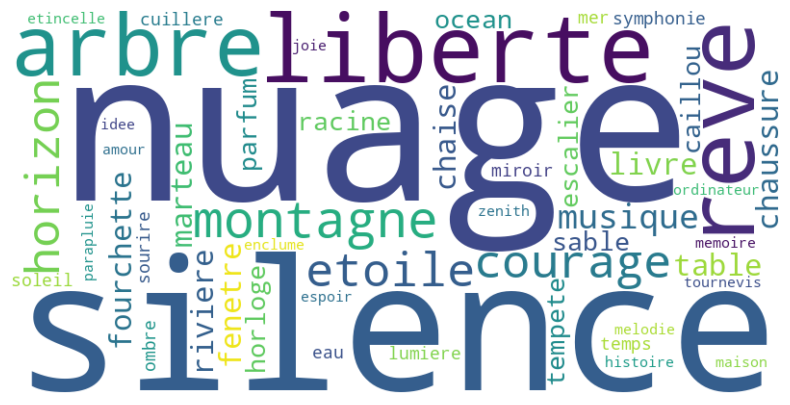

In [140]:
wordcloud_fr = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(all_words_fr)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fr, interpolation='bilinear')
plt.axis('off')
plt.show()

## Creativity score by age